# Byte Pair Encoding (BPE) Tokenizer
## Yoav Ram

Tokenization is the first step in every modern LLM pipeline: raw text is converted into a sequence of integer *token IDs* that the model processes. This notebook builds a **BPE tokenizer from scratch** in pure Python and analyzes it on the TinyStories corpus.

**Why this matters:**
- In previous language models we used *character-level* tokenization — one id per character.
- Real LLMs use *subword* tokenization. GPT-2/GPT-4 use BPE; LLaMA uses SentencePiece (also BPE-based).
- BPE lets the model see longer contexts with the same sequence length because common substrings are compressed into single tokens.

**What we build:**
1. BPE training algorithm (merge-based vocabulary construction)
2. Encode and decode functions
3. Vocabulary analysis — token frequency, length distribution
4. Compression ratio: how much shorter are token sequences vs character sequences?
5. Save the trained tokenizer to disk for use in `nanochat.ipynb`

The tokenizer state is just two plain Python objects: `vocab` (a list of token strings) and `merges` (a list of `(id_a, id_b)` pairs). No classes.

In [1]:
import re
import json
import pickle
import urllib.request
import collections
import matplotlib.pyplot as plt
import numpy as np

## The BPE algorithm

**Byte Pair Encoding** ([Sennrich et al., 2016](https://arxiv.org/abs/1508.07909)) was originally a text *compression* algorithm. 
Applied to tokenization:

1. Start with a vocabulary of all individual characters in the training corpus.
2. Count every adjacent pair of symbols.
3. Merge the most frequent pair into a new token, replacing all occurrences in the corpus.
4. Repeat until the vocabulary reaches the target size.

### Scaling trick: word frequencies

A naïve implementation scans the entire text on every merge step — too slow for large corpora.
The standard optimization (used by GPT-2) is to first split the text into *words* and count their frequencies. Pair counts are then accumulated over the unique words, weighted by frequency. This reduces the inner loop from billions of characters to hundreds of thousands of unique words, and also means merges cannot cross word boundaries.

### Toy example

Corpus: `"low low low lower lowest"`

| Step | Merge | Vocab | Tokens |
|------|-------|-------|--------|
| 0 | — | `{l,o,w,e,r,s,t,' '}` | `l o w   l o w   …` |
| 1 | `l+o→lo` | adds `lo` | `lo w   lo w   …` |
| 2 | `lo+w→low` | adds `low` | `low   low   …` |
| 3 | `low+e→lowe` | adds `lowe` | `low   low   lowe r   lowe st` |

Each merge step reduces total token count while adding one vocabulary entry. The algorithm stops when vocabulary size reaches the target (e.g., 512 or 50,000).

### Character-level vs BPE

| Property | Char-level | BPE |
|----------|-----------|-----|
| Vocab size | ~70 | 512 – 100k |
| Sequence length | long | shorter |
| Out-of-vocab | impossible | impossible (falls back to chars) |
| Common subwords | split across tokens | one token |
| Morphology | lost | partially preserved |

## Implementation

In [2]:
from bpe import bpe_train, bpe_encode, bpe_decode, bpe_save, bpe_load

In [3]:
%pycat bpe.py

import pickle


def bpe_train(text, vocab_size=512, verbose=True):
    """
    Train a BPE tokenizer on text.

    Returns:
        vocab  — list of token strings; index = token id
        merges — list of (id_a, id_b) merge rules in training order
    """
    chars = sorted(set(text))
    vocab = chars[:]
    encoder = {c: i for i, c in enumerate(chars)}
    ids = [encoder[c] for c in text]
    merges = []

    while len(vocab) < vocab_size:
        # Count adjacent pairs
        counts = {}
        for a, b in zip(ids, ids[1:]):
            counts[(a, b)] = counts.get((a, b), 0) + 1
        if not counts:
            break

        # Merge the most frequent pair
        best = max(counts, key=counts.get)
        new_tok = vocab[best[0]] + vocab[best[1]]
        new_id = len(vocab)
        vocab.append(new_tok)
        encoder[new_tok] = new_id
        merges.append(best)

        # Apply merge to the token stream
        merged, i = [], 0
        while i < len(ids):
            if i 

## Toy example: trace the merges

Verify on a small string so we can inspect every step.

In [4]:
toy = "low low low lower lowest"
vocab_toy, merges_toy = bpe_train(toy, vocab_size=15, verbose=False)

print("Merge rules learned:")
for i, (a, b) in enumerate(merges_toy):
    print(f"  {i+1:2d}: '{vocab_toy[a]}' + '{vocab_toy[b]}' → '{vocab_toy[a]+vocab_toy[b]}'")

print(f"\nFull vocabulary ({len(vocab_toy)} tokens):")
print(vocab_toy)

print("\nEncoding 'lowest':")
ids = bpe_encode('lowest', vocab_toy, merges_toy)
tokens = [vocab_toy[i] for i in ids]
print(f"  ids:    {ids}")
print(f"  tokens: {tokens}")
print(f"  decoded: {bpe_decode(ids, vocab_toy)!r}")

Merge rules learned:
   1: 'l' + 'o' → 'lo'
   2: 'lo' + 'w' → 'low'
   3: ' ' + 'low' → ' low'
   4: ' low' + ' low' → ' low low'
   5: ' low' + 'e' → ' lowe'
   6: 'low' + ' low low' → 'low low low'
   7: 'low low low' + ' lowe' → 'low low low lowe'

Full vocabulary (15 tokens):
[' ', 'e', 'l', 'o', 'r', 's', 't', 'w', 'lo', 'low', ' low', ' low low', ' lowe', 'low low low', 'low low low lowe']

Encoding 'lowest':
  ids:    [9, 1, 5, 6]
  tokens: ['low', 'e', 's', 't']
  decoded: 'lowest'


## Train on TinyStories

Download the training split of TinyStories and train a 1024-token vocabulary on it.

In [ ]:
URL = "https://huggingface.co/datasets/roneneldan/TinyStories/resolve/main/TinyStoriesV2-GPT4-train.txt"
CACHE = "data/TinyStoriesV2-GPT4-train.txt"

import os, urllib.request
if not os.path.exists(CACHE):
    print(f"Downloading TinyStories training split (~2 GB) …")
    urllib.request.urlretrieve(URL, CACHE)
    print("Done.")

with open(CACHE, encoding='utf-8') as f:
    raw = f.read()

stories = [s.strip() for s in raw.split('<|endoftext|>') if s.strip()]
text = '\n'.join(stories)
print(f"Stories: {len(stories):,}  |  Characters: {len(text):,}")

In [ ]:
%%time
VOCAB_SIZE = 1024   # was 512; larger vocab → better compression → shorter sequences
vocab, merges = bpe_train(text, vocab_size=VOCAB_SIZE)

## Vocabulary analysis

Inspect what the tokenizer learned: token length distribution, the longest tokens, and which single characters exist in the vocabulary.

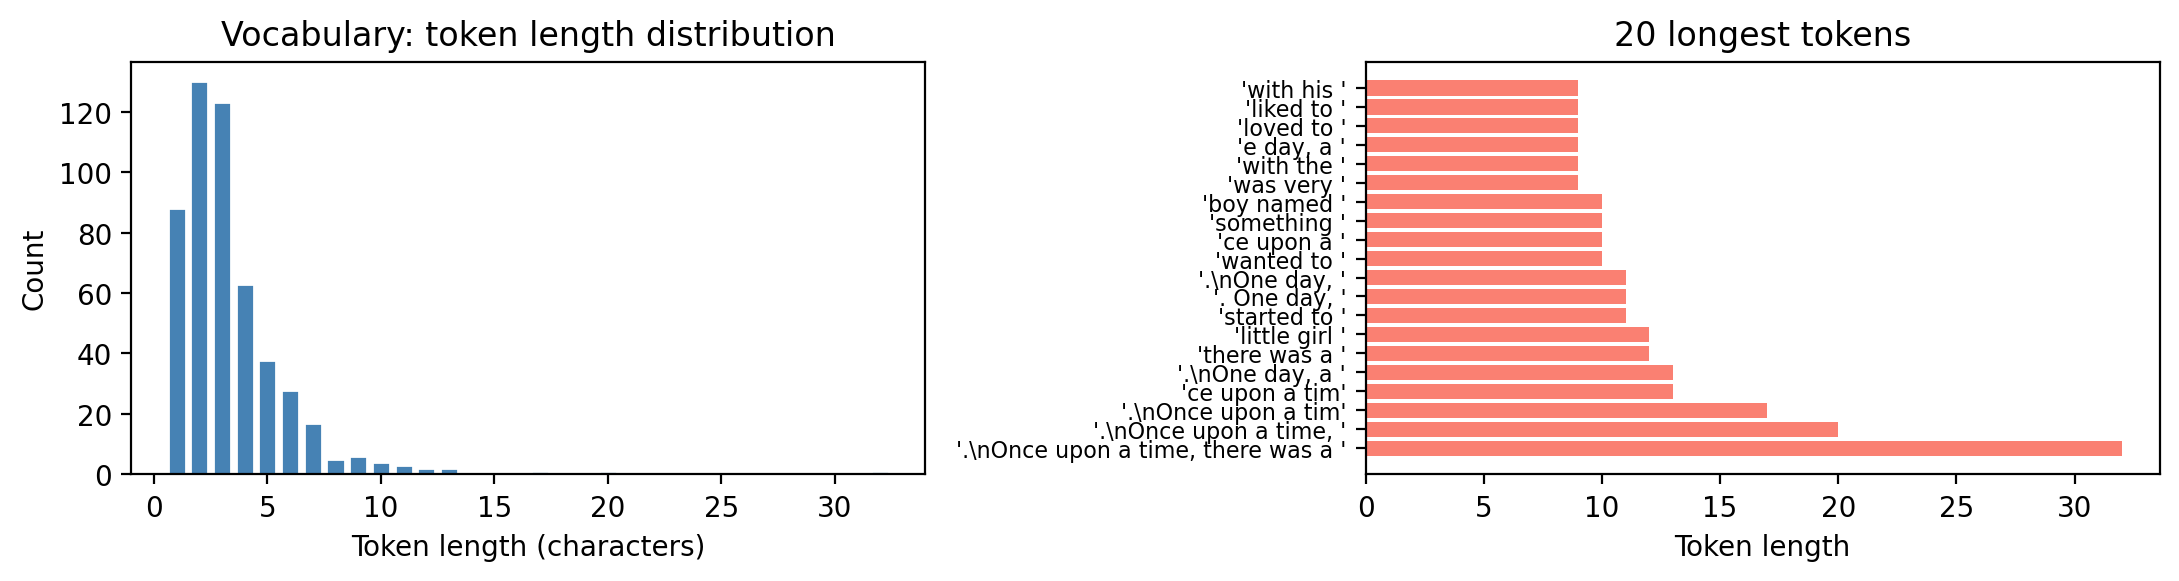


Character tokens (len=1): 88
Multi-char tokens:         424
Longest token: '.\nOnce upon a time, there was a '


In [7]:
token_lengths = [len(t) for t in vocab]

fig, axes = plt.subplots(1, 2, figsize=(11, 3))

axes[0].bar(range(1, max(token_lengths)+1),
            [token_lengths.count(l) for l in range(1, max(token_lengths)+1)],
            color='steelblue', edgecolor='white')
axes[0].set_xlabel('Token length (characters)')
axes[0].set_ylabel('Count')
axes[0].set_title('Vocabulary: token length distribution')

longest = sorted(vocab, key=len, reverse=True)[:20]
axes[1].barh(range(len(longest)), [len(t) for t in longest], color='salmon')
axes[1].set_yticks(range(len(longest)))
axes[1].set_yticklabels([repr(t) for t in longest], fontsize=8)
axes[1].set_xlabel('Token length')
axes[1].set_title('20 longest tokens')

plt.tight_layout()
plt.show()

print(f"\nCharacter tokens (len=1): {sum(1 for t in vocab if len(t)==1)}")
print(f"Multi-char tokens:         {sum(1 for t in vocab if len(t)>1)}")
print(f"Longest token: {repr(max(vocab, key=len))}")

## Compression ratio

How many fewer tokens does BPE produce compared to a character-level representation?

$$\text{compression ratio} = \frac{\text{characters}}{\text{BPE tokens}}$$

A ratio of 2 means each BPE token represents 2 characters on average — the model sees 2× more context within the same sequence length.

Characters:         156,820
BPE tokens:         55,076
Compression ratio:  2.85×
  vocab=  64  ratio=1.00×
  vocab= 128  ratio=1.51×
  vocab= 256  ratio=2.14×
  vocab= 512  ratio=2.85×


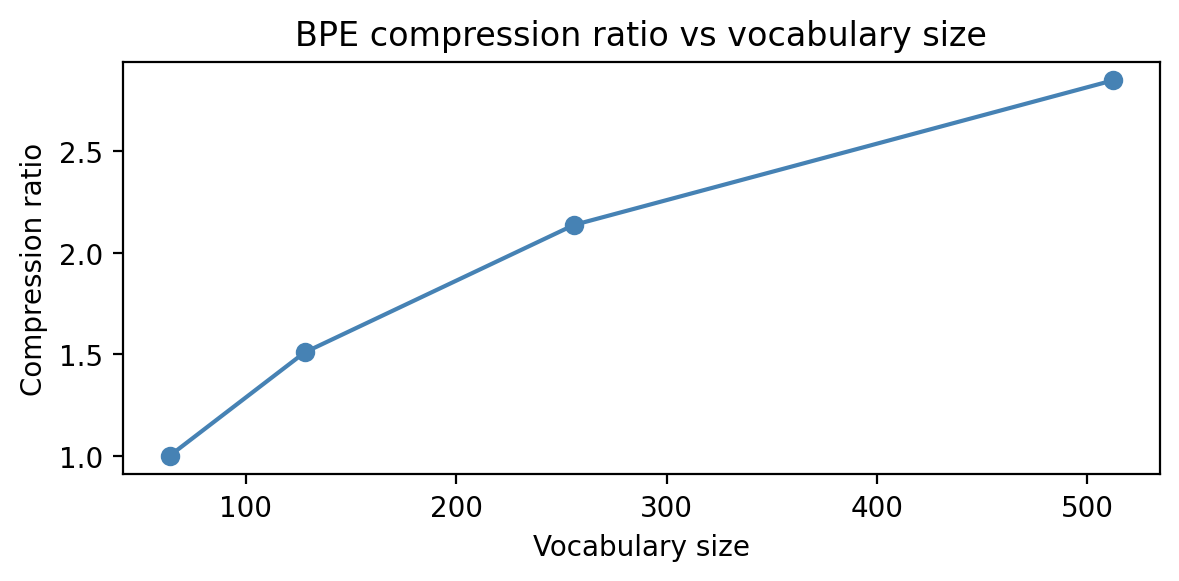

In [8]:
sample_text = '\n'.join(stories[:200])

char_tokens = len(sample_text)
bpe_tokens  = len(bpe_encode(sample_text, vocab, merges))

ratio = char_tokens / bpe_tokens
print(f"Characters:         {char_tokens:,}")
print(f"BPE tokens:         {bpe_tokens:,}")
print(f"Compression ratio:  {ratio:.2f}×")

vocab_sizes = [64, 128, 256, 512]
ratios = []
for vs in vocab_sizes:
    v, m = bpe_train(text, vocab_size=vs, verbose=False)
    ratios.append(len(sample_text) / len(bpe_encode(sample_text, v, m)))
    print(f"  vocab={vs:4d}  ratio={ratios[-1]:.2f}×")

plt.figure(figsize=(6, 3))
plt.plot(vocab_sizes, ratios, marker='o', color='steelblue')
plt.xlabel('Vocabulary size')
plt.ylabel('Compression ratio')
plt.title('BPE compression ratio vs vocabulary size')
plt.tight_layout()
plt.show()

## Tokenize some examples

See how the tokenizer segments different kinds of text.

In [9]:
examples = [
    "Once upon a time there was a little cat.",
    "The princess lived in a tall castle.",
    "abcdefghijklmnopqrstuvwxyz",
]

for ex in examples:
    ids  = bpe_encode(ex, vocab, merges)
    toks = [vocab[i] for i in ids]
    print(f"Input:  {ex!r}")
    print(f"Tokens: {toks}")
    print(f"IDs:    {ids}")
    print(f"Ratio:  {len(ex)/len(ids):.2f}×")
    print()

Input:  'Once upon a time there was a little cat.'
Tokens: ['On', 'ce upon a tim', 'e ', 'there was a ', 'little ', 'cat', '.']
IDs:    [155, 276, 88, 280, 224, 468, 7]
Ratio:  5.71×

Input:  'The princess lived in a tall castle.'
Tokens: ['The ', 'p', 'r', 'in', 'c', 'es', 's ', 'lived ', 'in a ', 'ta', 'll ', 'ca', 'st', 'le', '.']
IDs:    [242, 65, 67, 103, 52, 229, 95, 508, 447, 284, 163, 287, 139, 164, 7]
Ratio:  2.40×

Input:  'abcdefghijklmnopqrstuvwxyz'
Tokens: ['a', 'b', 'c', 'd', 'e', 'f', 'gh', 'i', 'j', 'k', 'l', 'm', 'no', 'p', 'q', 'r', 'st', 'u', 'v', 'w', 'x', 'y', 'z']
IDs:    [50, 51, 52, 53, 54, 55, 190, 58, 59, 60, 61, 62, 149, 65, 66, 67, 139, 70, 71, 72, 73, 74, 75]
Ratio:  1.13×



## Save the tokenizer

Save the trained tokenizer to `bpe_tokenizer.pkl`. This file is loaded by `nanochat.ipynb` so we don't need to retrain every time.

In [10]:
bpe_save(vocab, merges, 'bpe_tokenizer.pkl')

# Verify round-trip
vocab2, merges2 = bpe_load('bpe_tokenizer.pkl')
test = "Once upon a time there was a fox."
assert bpe_decode(bpe_encode(test, vocab2, merges2), vocab2) == test
print(f"Round-trip OK: {test!r}")

Saved tokenizer to bpe_tokenizer.pkl
Round-trip OK: 'Once upon a time there was a fox.'


# Note on performance

The BPE functions (`bpe_train`, `bpe_encode`, `bpe_decode`) are pure Python and intentionally so: they operate on Python `list`, `dict`, and `str` objects that are incompatible with both NumPy (which requires numeric arrays) and JAX (which requires static shapes and no data-dependent control flow). The key optimization in `bpe_train` is the **word-frequency table**: instead of scanning the full text (~2B characters) on every merge step, we split into unique words and weight pair counts by frequency. This reduces the inner loop to ~500K unique words and makes training on the full TinyStories corpus feasible in minutes.
At production scale, the right move is to replace this implementation with HuggingFace's [tokenizers](https://huggingface.co/docs/tokenizers/index), a Rust library that is 100-1000x faster.

## Exercises

1. **Vocabulary size ablation.** Train tokenizers with vocab sizes 64, 128, 256, 512, 1024. Plot compression ratio and the 10 longest tokens for each. Where does increasing vocab size stop helping?

2. **Byte-level BPE.** Modify `train()` to operate on UTF-8 *bytes* rather than characters (encode each character as `c.encode('utf-8')` first). How does this change the vocabulary for text with accented characters?

3. **Merge order.** Print the first 20 and last 20 merge rules. What patterns do you see? Why are spaces merged early?

4. **Out-of-distribution text.** Encode a sentence in another language (e.g., Spanish or French). Count how many tokens fall back to character-level. How does the compression ratio compare?

5. **Tokenization ambiguity.** Is BPE encoding deterministic? Can the same string be tokenized in multiple ways? Why or why not?

6. **Token frequency.** Encode the full corpus and count token frequencies. Plot a Zipf plot (rank vs frequency on log-log axes). Does token frequency follow a power law?